# Preprocessing

In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from sklearn.utils import resample

In [ ]:
# CONFIG
IMG_SIZE = (160, 160)
BENIGN_TYPES    = ['df', 'bkl', 'vasc', 'nv']
MALIGNANT_TYPES = ['bcc', 'mel', 'akiec']
LABEL_MAP = {'Benign': 0, 'Malignant': 1}
IMG_DIR = Path(r"C:\Users\LENOVO\OneDrive - Asia Pacific University\Desktop\Assinments APU\sem3\project\Project_AI\HAM10000_images")
df = pd.read_csv("HAM10000_metadata.csv")  # contains columns “image_id”, “dx”, etc.

# Create a “diagnosis_group” column of strings "Benign"/"Malignant"
df['diagnosis_group'] = df['dx'].apply(
    lambda x: 'Benign' if x in BENIGN_TYPES else ('Malignant' if x in MALIGNANT_TYPES else np.nan)
)
df = df.dropna(subset=['diagnosis_group']).reset_index(drop=True)

# Split into benign vs malignant
df_benign = df[df['diagnosis_group']=='Benign']
df_malig  = df[df['diagnosis_group']=='Malignant']

# Randomly sample from benign to match malignant count
df_ben_half = df_benign.sample(frac=0.5, random_state=42)
print("After partial undersampling:", df_ben_half['diagnosis_group'].value_counts().to_dict())

# Oversample malignant to match full benign count
df_mal_upsampled = resample(df_malig,
                            replace=True,
                            n_samples=len(df_benign),
                            random_state=42)
print("After oversampling malignant:", df_mal_upsampled['diagnosis_group'].value_counts().to_dict())

# Combine into final balanced dataset
df_bal = pd.concat([df_benign, df_mal_upsampled]).reset_index(drop=True)


# Attach full filepaths
all_paths = list(IMG_DIR.rglob("*.jpg"))
id2path = {p.stem: p for p in all_paths}
df_bal['path'] = df_bal['image_id'].map(id2path)
df_bal = df_bal.dropna(subset=['path']).reset_index(drop=True)

# Map “Benign”→0, “Malignant”→1
df_bal['label'] = df_bal['diagnosis_group'].map(LABEL_MAP)

print(f"Balanced dataset size: {len(df_bal)}  (should be 3,908)")

After partial undersampling: {'Benign': 4030}
After oversampling malignant: {'Malignant': 8061}
Balanced dataset size: 16122  (should be 3,908)


Final class balance (label counts):
label
0    8061
1    8061
Name: count, dtype: int64


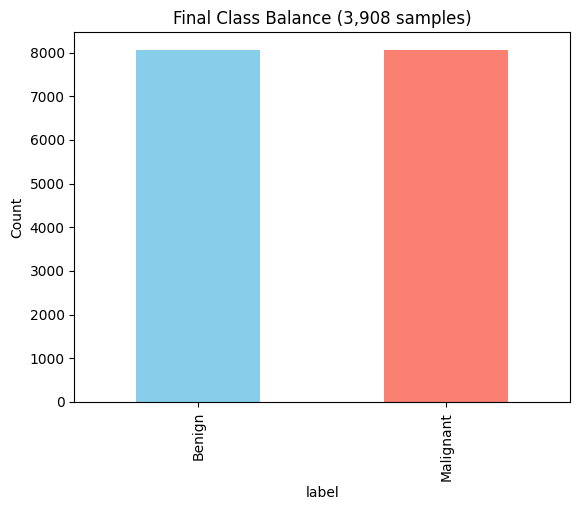

In [3]:
print("Final class balance (label counts):")
print(df_bal['label'].value_counts())

# Optional: Plot a bar chart
import matplotlib.pyplot as plt

df_bal['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.title("Final Class Balance (3,908 samples)")
plt.ylabel("Count")
plt.show()


In [4]:
# Data generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    rescale=1./255
)

# Load original color images
def load_images(indexes):
    images, labels = [], []
    for idx in indexes:
        img_bgr = cv2.imread(df_bal.loc[idx, "path"])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMG_SIZE)
        images.append(img_resized)
        labels.append(df_bal.loc[idx, "label"])
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

# Train/val/test split
train_idx, test_idx = train_test_split(df_bal.index, test_size=0.3, stratify=df_bal['label'], random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, stratify=df_bal.loc[train_idx, 'label'], random_state=42)
X_train, y_train = load_images(train_idx)
X_val, y_val = load_images(val_idx)
X_test, y_test = load_images(test_idx)


In [5]:
# Check class balance in train, validation, and test
print("Train class balance:")
print(pd.Series(y_train).value_counts())

print("\nValidation class balance:")
print(pd.Series(y_val).value_counts())

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())


Train class balance:
1    4514
0    4514
Name: count, dtype: int64

Validation class balance:
1    1129
0    1128
Name: count, dtype: int64

Test class balance:
0    2419
1    2418
Name: count, dtype: int64


# MobileNetV2

## Model Building

In [6]:
# Load MobileNetV2 base (no top, pretrained weights)
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Freeze base model
base_model.trainable = False

# Add classifier head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=20
)


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.5630 - loss: 0.7703 - val_accuracy: 0.6801 - val_loss: 0.6045
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.6435 - loss: 0.6574 - val_accuracy: 0.7313 - val_loss: 0.5464
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.7018 - loss: 0.5952 - val_accuracy: 0.7276 - val_loss: 0.5405
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.7185 - loss: 0.5849 - val_accuracy: 0.7386 - val_loss: 0.5337
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.7424 - loss: 0.5244 - val_accuracy: 0.7404 - val_loss: 0.5369
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.7325 - loss: 0.5462 - val_accuracy: 0.7422 - val_loss: 0.5244
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.7517 - loss: 0.5221 - val_accuracy: 0.7331 - val_loss: 0.5238
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.7512 - loss: 0.5165 - val_accuracy: 0.7477 - val_loss:

In [8]:
# Best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
print("Best epoch:", best_epoch)
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best epoch: 20
Training Accuracy: 0.7733
Validation Accuracy: 0.7550
Training Loss: 0.4823
Validation Loss: 0.4937


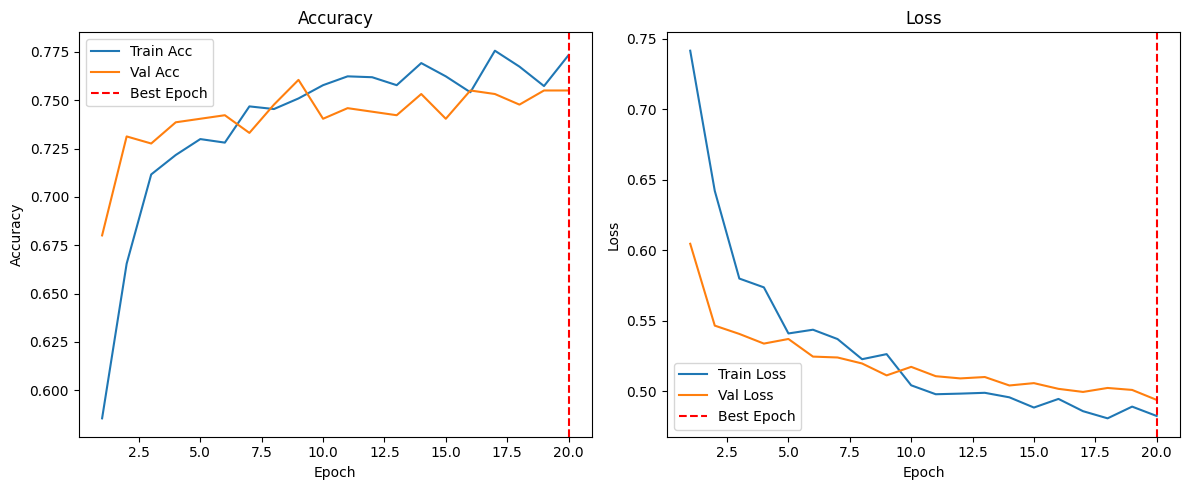

In [9]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)


37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 455ms/step - accuracy: 0.7498 - loss: 0.5068
Test accuracy: 0.7595908045768738
Test loss:  0.4915383458137512


In [11]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > 0.5).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 649ms/step
Confusion Matrix:
 [[425 162]
 [120 466]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75       587
           1       0.74      0.80      0.77       586

    accuracy                           0.76      1173
   macro avg       0.76      0.76      0.76      1173
weighted avg       0.76      0.76      0.76      1173



## learning rate for validation loss

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce learning rate when val_loss plateaus
lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, 
    patience=3,              
    verbose=1,
    min_lr=1e-6            
)

# Train with the callback
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=20,
    callbacks=[lr_reduction]
)


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5799 - loss: 0.8597 - val_accuracy: 0.7112 - val_loss: 0.5920 - learning_rate: 1.0000e-04
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6269 - loss: 0.7036 - val_accuracy: 0.7258 - val_loss: 0.5600 - learning_rate: 1.0000e-04
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6712 - loss: 0.6211 - val_accuracy: 0.7441 - val_loss: 0.5373 - learning_rate: 1.0000e-04
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7296 - loss: 0.5671 - val_accuracy: 0.7294 - val_loss: 0.5541 - learning_rate: 1.0000e-04
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7335 - loss: 0.5452 - val_accuracy: 0.7331 - val_loss: 0.5341 - learning_rate: 1.0000e-04
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7435 - loss: 0.5376 - val_accuracy: 0.7386 - val_loss: 0.5297 - learning_rate: 1.0000e-04
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7341 - loss:

In [8]:
# Best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
print("Best epoch:", best_epoch)
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best epoch: 19
Training Accuracy: 0.7610
Validation Accuracy: 0.7569
Training Loss: 0.4939
Validation Loss: 0.5025


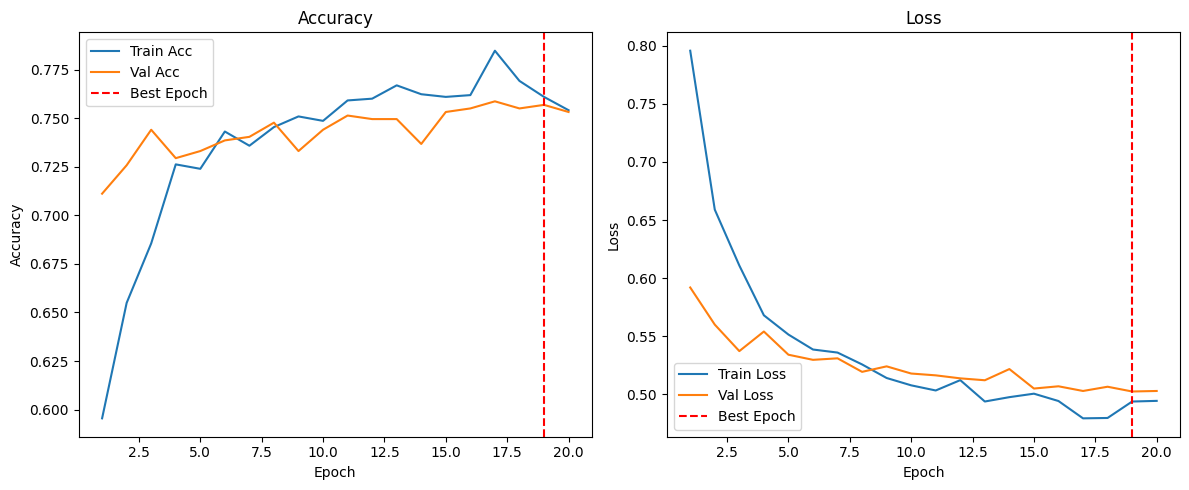

In [9]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)


37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - accuracy: 0.7401 - loss: 0.5101
Test accuracy: 0.7450980544090271
Test loss:  0.5017021298408508


In [14]:
from sklearn.metrics import precision_recall_fscore_support

best_threshold = None
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)

# Corrected: no y_test here
y_pred_probs = model.predict(X_test / 255.0, verbose=0)

for thresh in thresholds:
    y_pred_thresh = (y_pred_probs > thresh).astype("int32").flatten()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    gap = abs(precision - recall)
    
    if gap <= 0.1 and precision >= recall * 0.9 and recall >= precision * 0.9:
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

print(f"Best threshold (precision-recall gap ≤ 10%): {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")


Best threshold (precision-recall gap ≤ 10%): 0.53
Best F1-score: 0.7624


In [15]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > 0.53).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step
Confusion Matrix:
 [[410 177]
 [116 470]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74       587
           1       0.73      0.80      0.76       586

    accuracy                           0.75      1173
   macro avg       0.75      0.75      0.75      1173
weighted avg       0.75      0.75      0.75      1173



## early stopping for validation loss

In [6]:
# Load MobileNetV2 base (no top, pretrained weights)
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Freeze base model
base_model.trainable = False

# Add classifier head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce learning rate when val_loss plateaus
lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',    
    factor=0.5,            
    patience=3,          
    verbose=1,
    min_lr=1e-6   
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# Train with the callback
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[lr_reduction, early_stop],
    verbose = 1
)


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.4887 - loss: 0.9338 - val_accuracy: 0.6197 - val_loss: 0.6706 - learning_rate: 1.0000e-04
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6121 - loss: 0.7166 - val_accuracy: 0.7002 - val_loss: 0.5825 - learning_rate: 1.0000e-04
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6873 - loss: 0.6303 - val_accuracy: 0.7331 - val_loss: 0.5646 - learning_rate: 1.0000e-04
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6724 - loss: 0.5996 - val_accuracy: 0.7258 - val_loss: 0.5667 - learning_rate: 1.0000e-04
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7100 - loss: 0.5875 - val_accuracy: 0.7367 - val_loss: 0.5380 - learning_rate: 1.0000e-04
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7301 - loss: 0.5487 - val_accuracy: 0.7349 - val_loss: 0.5462 - learning_rate: 1.0000e-04
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7160 

In [9]:
# Best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
print("Best epoch:", best_epoch)
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best epoch: 34
Training Accuracy: 0.7678
Validation Accuracy: 0.7569
Training Loss: 0.4623
Validation Loss: 0.4964


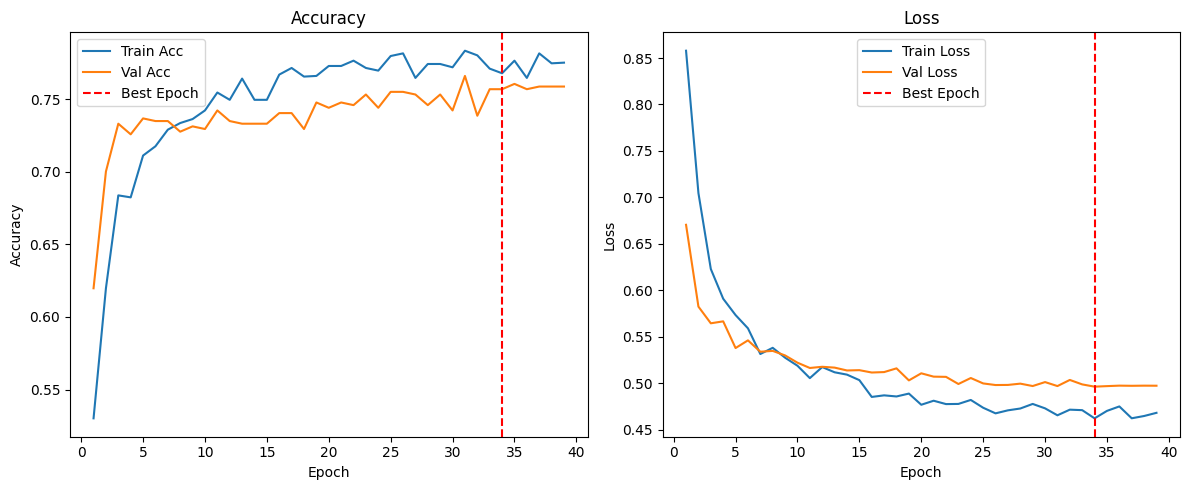

In [10]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)

Test accuracy: 0.7476555705070496
Test loss:  0.49112850427627563


In [13]:
from sklearn.metrics import precision_recall_fscore_support

best_threshold = None
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)

# Corrected: no y_test here
y_pred_probs = model.predict(X_test / 255.0, verbose=0)

for thresh in thresholds:
    y_pred_thresh = (y_pred_probs > thresh).astype("int32").flatten()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    gap = abs(precision - recall)
    
    if gap <= 0.1 and precision >= recall * 0.9 and recall >= precision * 0.9:
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

print(f"Best threshold (precision-recall gap ≤ 10%): {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")


Best threshold (precision-recall gap ≤ 10%): 0.53
Best F1-score: 0.7614


In [14]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > best_threshold).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 461ms/step
Confusion Matrix:
 [[423 164]
 [125 461]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.75       587
           1       0.74      0.79      0.76       586

    accuracy                           0.75      1173
   macro avg       0.75      0.75      0.75      1173
weighted avg       0.75      0.75      0.75      1173



## Using higher resolution 160

In [6]:
# Load MobileNetV2 base (no top, pretrained weights)
base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')

# Freeze base model
base_model.trainable = False

# Add classifier head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce learning rate when val_loss plateaus
lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',      # monitor validation loss
    factor=0.5,              # reduce by half
    patience=3,              # wait 3 epochs for improvement
    verbose=1,
    min_lr=1e-6              # lower bound
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# Train with the callback
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[lr_reduction, early_stop],
    verbose = 1
)


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.4925 - loss: 0.9212 - val_accuracy: 0.5978 - val_loss: 0.6694 - learning_rate: 1.0000e-04
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.5903 - loss: 0.7390 - val_accuracy: 0.6764 - val_loss: 0.6000 - learning_rate: 1.0000e-04
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6674 - loss: 0.6395 - val_accuracy: 0.6837 - val_loss: 0.5862 - learning_rate: 1.0000e-04
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.6869 - loss: 0.6215 - val_accuracy: 0.6910 - val_loss: 0.5628 - learning_rate: 1.0000e-04
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7131 - loss: 0.5871 - val_accuracy: 0.7020 - val_loss: 0.5538 - learning_rate: 1.0000e-04
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7177 - loss: 0.5685 - val_accuracy: 0.6947 - val_loss: 0.5590 - learning_rate: 1.0000e-04
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7114 

In [8]:
# Best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
print("Best epoch:", best_epoch)
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best epoch: 18
Training Accuracy: 0.7601
Validation Accuracy: 0.7331
Training Loss: 0.5008
Validation Loss: 0.5234


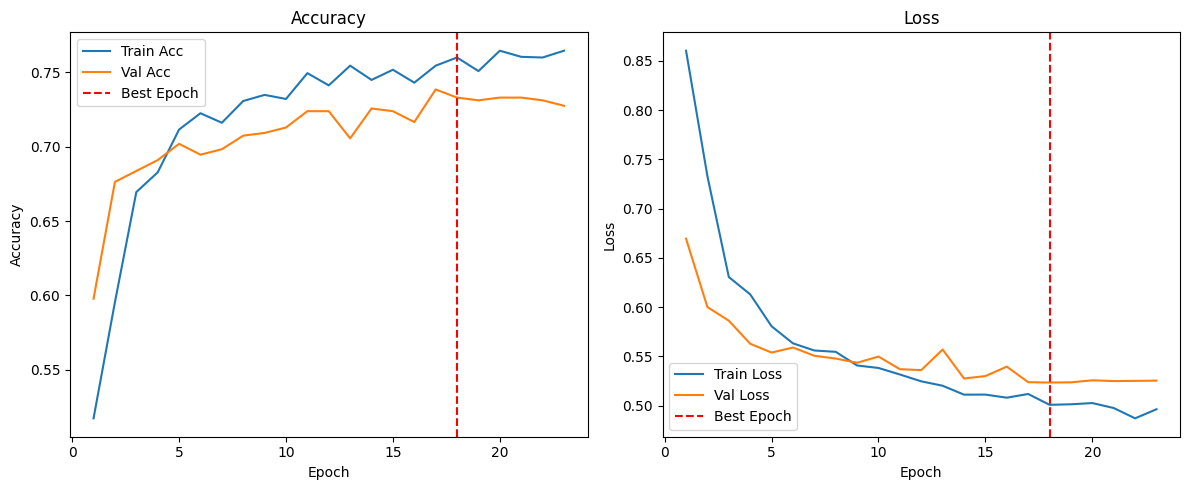

In [9]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)

Test accuracy: 0.7476555705070496
Test loss:  0.5165104269981384


In [11]:
from sklearn.metrics import precision_recall_fscore_support

best_threshold = None
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)

# Corrected: no y_test here
y_pred_probs = model.predict(X_test / 255.0, verbose=0)

for thresh in thresholds:
    y_pred_thresh = (y_pred_probs > thresh).astype("int32").flatten()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    gap = abs(precision - recall)
    
    if gap <= 0.1 and precision >= recall * 0.9 and recall >= precision * 0.9:
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

print(f"Best threshold (precision-recall gap ≤ 10%): {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")


Best threshold (precision-recall gap ≤ 10%): 0.52
Best F1-score: 0.7606


In [12]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > best_threshold).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 646ms/step
Confusion Matrix:
 [[412 175]
 [119 467]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74       587
           1       0.73      0.80      0.76       586

    accuracy                           0.75      1173
   macro avg       0.75      0.75      0.75      1173
weighted avg       0.75      0.75      0.75      1173



## Unfreezing layers

In [6]:

base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = True

# Freeze most layers, unfreeze last 20 layers only
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Classifier head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,370,177 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [7]:
lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# Train with the callback
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[lr_reduction, early_stop],
    verbose = 1
)



C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 577s 7s/step - accuracy: 0.6794 - loss: 0.6017 - val_accuracy: 0.5051 - val_loss: 1.2244 - learning_rate: 1.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 460s 6s/step - accuracy: 0.7844 - loss: 0.4570 - val_accuracy: 0.5308 - val_loss: 1.0830 - learning_rate: 1.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 461s 6s/step - accuracy: 0.8080 - loss: 0.4143 - val_accuracy: 0.5281 - val_loss: 1.1616 - learning_rate: 1.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 446s 6s/step - accuracy: 0.8249 - loss: 0.3904 - val_accuracy: 0.6057 - val_loss: 0.7931 - learning_rate: 1.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 447s 6s/step - accuracy: 0.8349 - loss: 0.3673 - val_accuracy: 0.6965 - val_loss: 0.5932 - learning_rate: 1.0000e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 411s 6s/step - accuracy: 0.8465 - loss: 0.3487 - val_accuracy: 0.7018 - val_loss: 0.5859 - learning_rate: 1.0000e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 412s 5s/step - accuracy: 

In [8]:
# Best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
print("Best epoch:", best_epoch)
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best epoch: 14
Training Accuracy: 0.9026
Validation Accuracy: 0.8281
Training Loss: 0.2305
Validation Loss: 0.3830


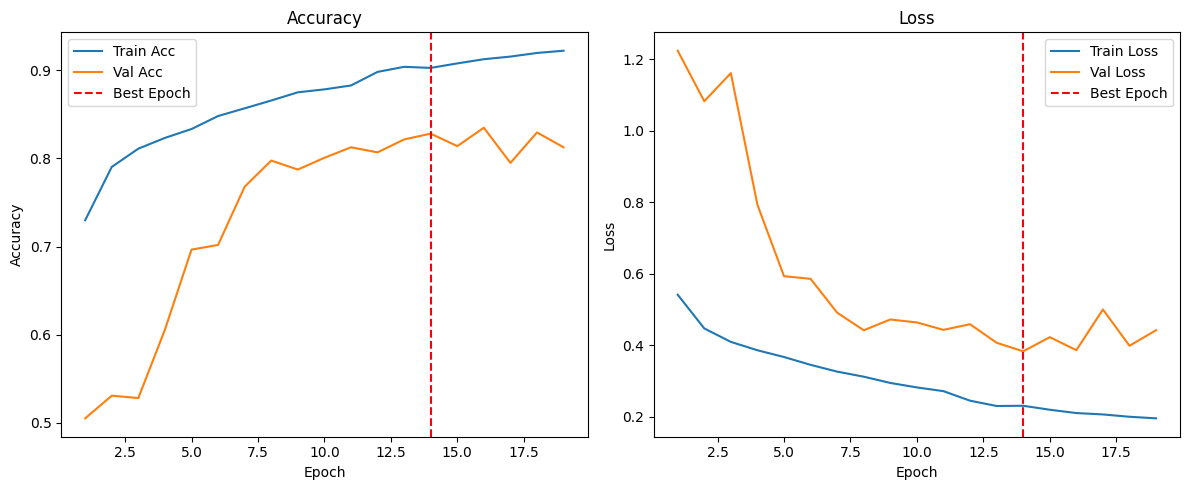

In [9]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)

Test accuracy: 0.8306801915168762
Test loss:  0.39947453141212463


In [11]:
from sklearn.metrics import precision_recall_fscore_support

best_threshold = None
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)

# Corrected: no y_test here
y_pred_probs = model.predict(X_test / 255.0, verbose=0)

for thresh in thresholds:
    y_pred_thresh = (y_pred_probs > thresh).astype("int32").flatten()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    gap = abs(precision - recall)
    
    if gap <= 0.1 and precision >= recall * 0.9 and recall >= precision * 0.9:
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

print(f"Best threshold (precision-recall gap ≤ 10%): {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")


Best threshold (precision-recall gap ≤ 10%): 0.51
Best F1-score: 0.8397


In [12]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > best_threshold).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

152/152 ━━━━━━━━━━━━━━━━━━━━ 93s 614ms/step
Confusion Matrix:
 [[1876  543]
 [ 275 2143]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82      2419
           1       0.80      0.89      0.84      2418

    accuracy                           0.83      4837
   macro avg       0.83      0.83      0.83      4837
weighted avg       0.84      0.83      0.83      4837



## Tweaking

In [23]:

base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = True

# Freeze most layers, unfreeze last 20 layers only
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Classifier head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 896,577 (3.42 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

In [24]:
lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# Train with the callback
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[lr_reduction, early_stop],
    verbose = 1
)



C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.6576 - loss: 0.6560 - val_accuracy: 0.5033 - val_loss: 1.3178 - learning_rate: 1.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.7753 - loss: 0.4831 - val_accuracy: 0.5095 - val_loss: 1.3377 - learning_rate: 1.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 413s 6s/step - accuracy: 0.7892 - loss: 0.4579 - val_accuracy: 0.5082 - val_loss: 1.7129 - learning_rate: 1.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7934 - loss: 0.4420
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
71/71 ━━━━━━━━━━━━━━━━━━━━ 470s 7s/step - accuracy: 0.7934 - loss: 0.4419 - val_accuracy: 0.5250 - val_loss: 1.3599 - learning_rate: 1.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 509s 7s/step - accuracy: 0.8047 - loss: 0.4289 - val_accuracy: 0.5840 - val_loss: 0.9749 - learning_rate: 5.0000e-05
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 500s 7s/step - accuracy: 0.8094 -

In [25]:
# Best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
print("Best epoch:", best_epoch)
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best epoch: 65
Training Accuracy: 0.8908
Validation Accuracy: 0.8808
Training Loss: 0.2638
Validation Loss: 0.2973


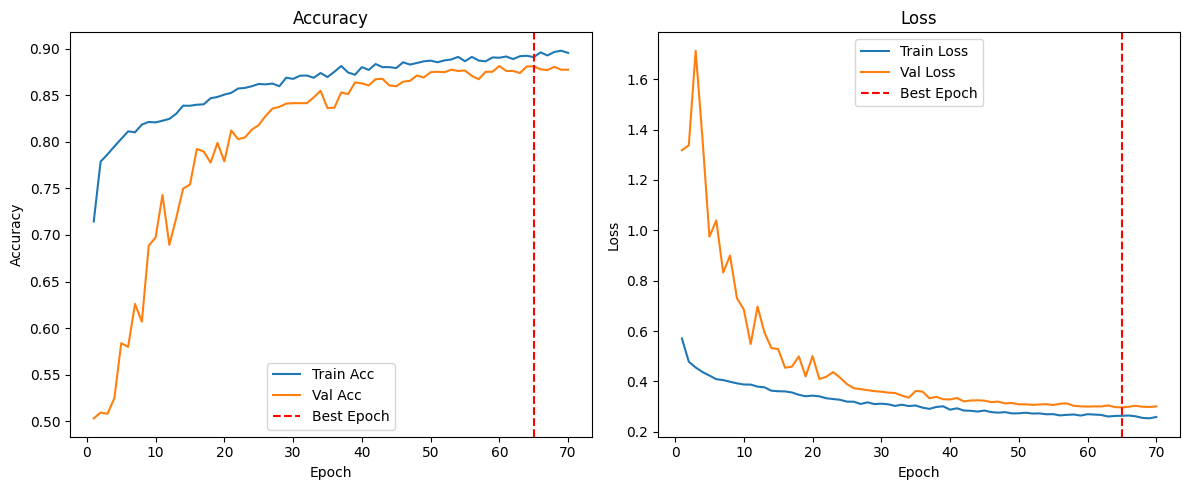

In [26]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [27]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)

Test accuracy: 0.8649989366531372
Test loss:  0.3160448968410492


In [28]:
from sklearn.metrics import precision_recall_fscore_support

best_threshold = None
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)

# Corrected: no y_test here
y_pred_probs = model.predict(X_test / 255.0, verbose=0)

for thresh in thresholds:
    y_pred_thresh = (y_pred_probs > thresh).astype("int32").flatten()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    gap = abs(precision - recall)
    
    if gap <= 0.1 and precision >= recall * 0.9 and recall >= precision * 0.9:
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

print(f"Best threshold (precision-recall gap ≤ 10%): {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")


Best threshold (precision-recall gap ≤ 10%): 0.55
Best F1-score: 0.8722


In [29]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > best_threshold).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

152/152 ━━━━━━━━━━━━━━━━━━━━ 52s 341ms/step
Confusion Matrix:
 [[2005  414]
 [ 228 2190]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.83      0.86      2419
           1       0.84      0.91      0.87      2418

    accuracy                           0.87      4837
   macro avg       0.87      0.87      0.87      4837
weighted avg       0.87      0.87      0.87      4837



In [30]:
model.save('best_MobileNetV2.keras')